In [1]:
import pandas as pd

# Análise dos dados e pré-processamento 

In [9]:
uri = r'C:\Users\Usuario\Documents\Estudos\FIAP\Fase4\raw\seeds_dataset.txt'

colunas = ['area', 'perimetro', 'compacidade', 'comprimento_nucleo', 'largura_nucleo', 
           'coef_assimetria', 'comprimento_sulco_nucleo', 'classe_grao']

def carregar_transformar(data=uri): 
    try: 
        df = pd.read_csv(uri, header=None, sep='\s+', engine='python')
        df.columns = colunas
        return df 
    except Exception as e: 
        print(e)

<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_408\3973117163.py:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv(uri, header=None, sep='\s+', engine='python')


In [10]:
df = carregar_transformar()
df.head()

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco_nucleo,classe_grao
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   area                      210 non-null    float64
 1   perimetro                 210 non-null    float64
 2   compacidade               210 non-null    float64
 3   comprimento_nucleo        210 non-null    float64
 4   largura_nucleo            210 non-null    float64
 5   coef_assimetria           210 non-null    float64
 6   comprimento_sulco_nucleo  210 non-null    float64
 7   classe_grao               210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB
None


# Cálculo das estatísticas descritivas

In [14]:
df.describe()

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco_nucleo,classe_grao
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [22]:
df['classe_grao'].value_counts()

classe_grao
1    70
2    70
3    70
Name: count, dtype: int64

# Visualização utilizando histogramas e boxplots

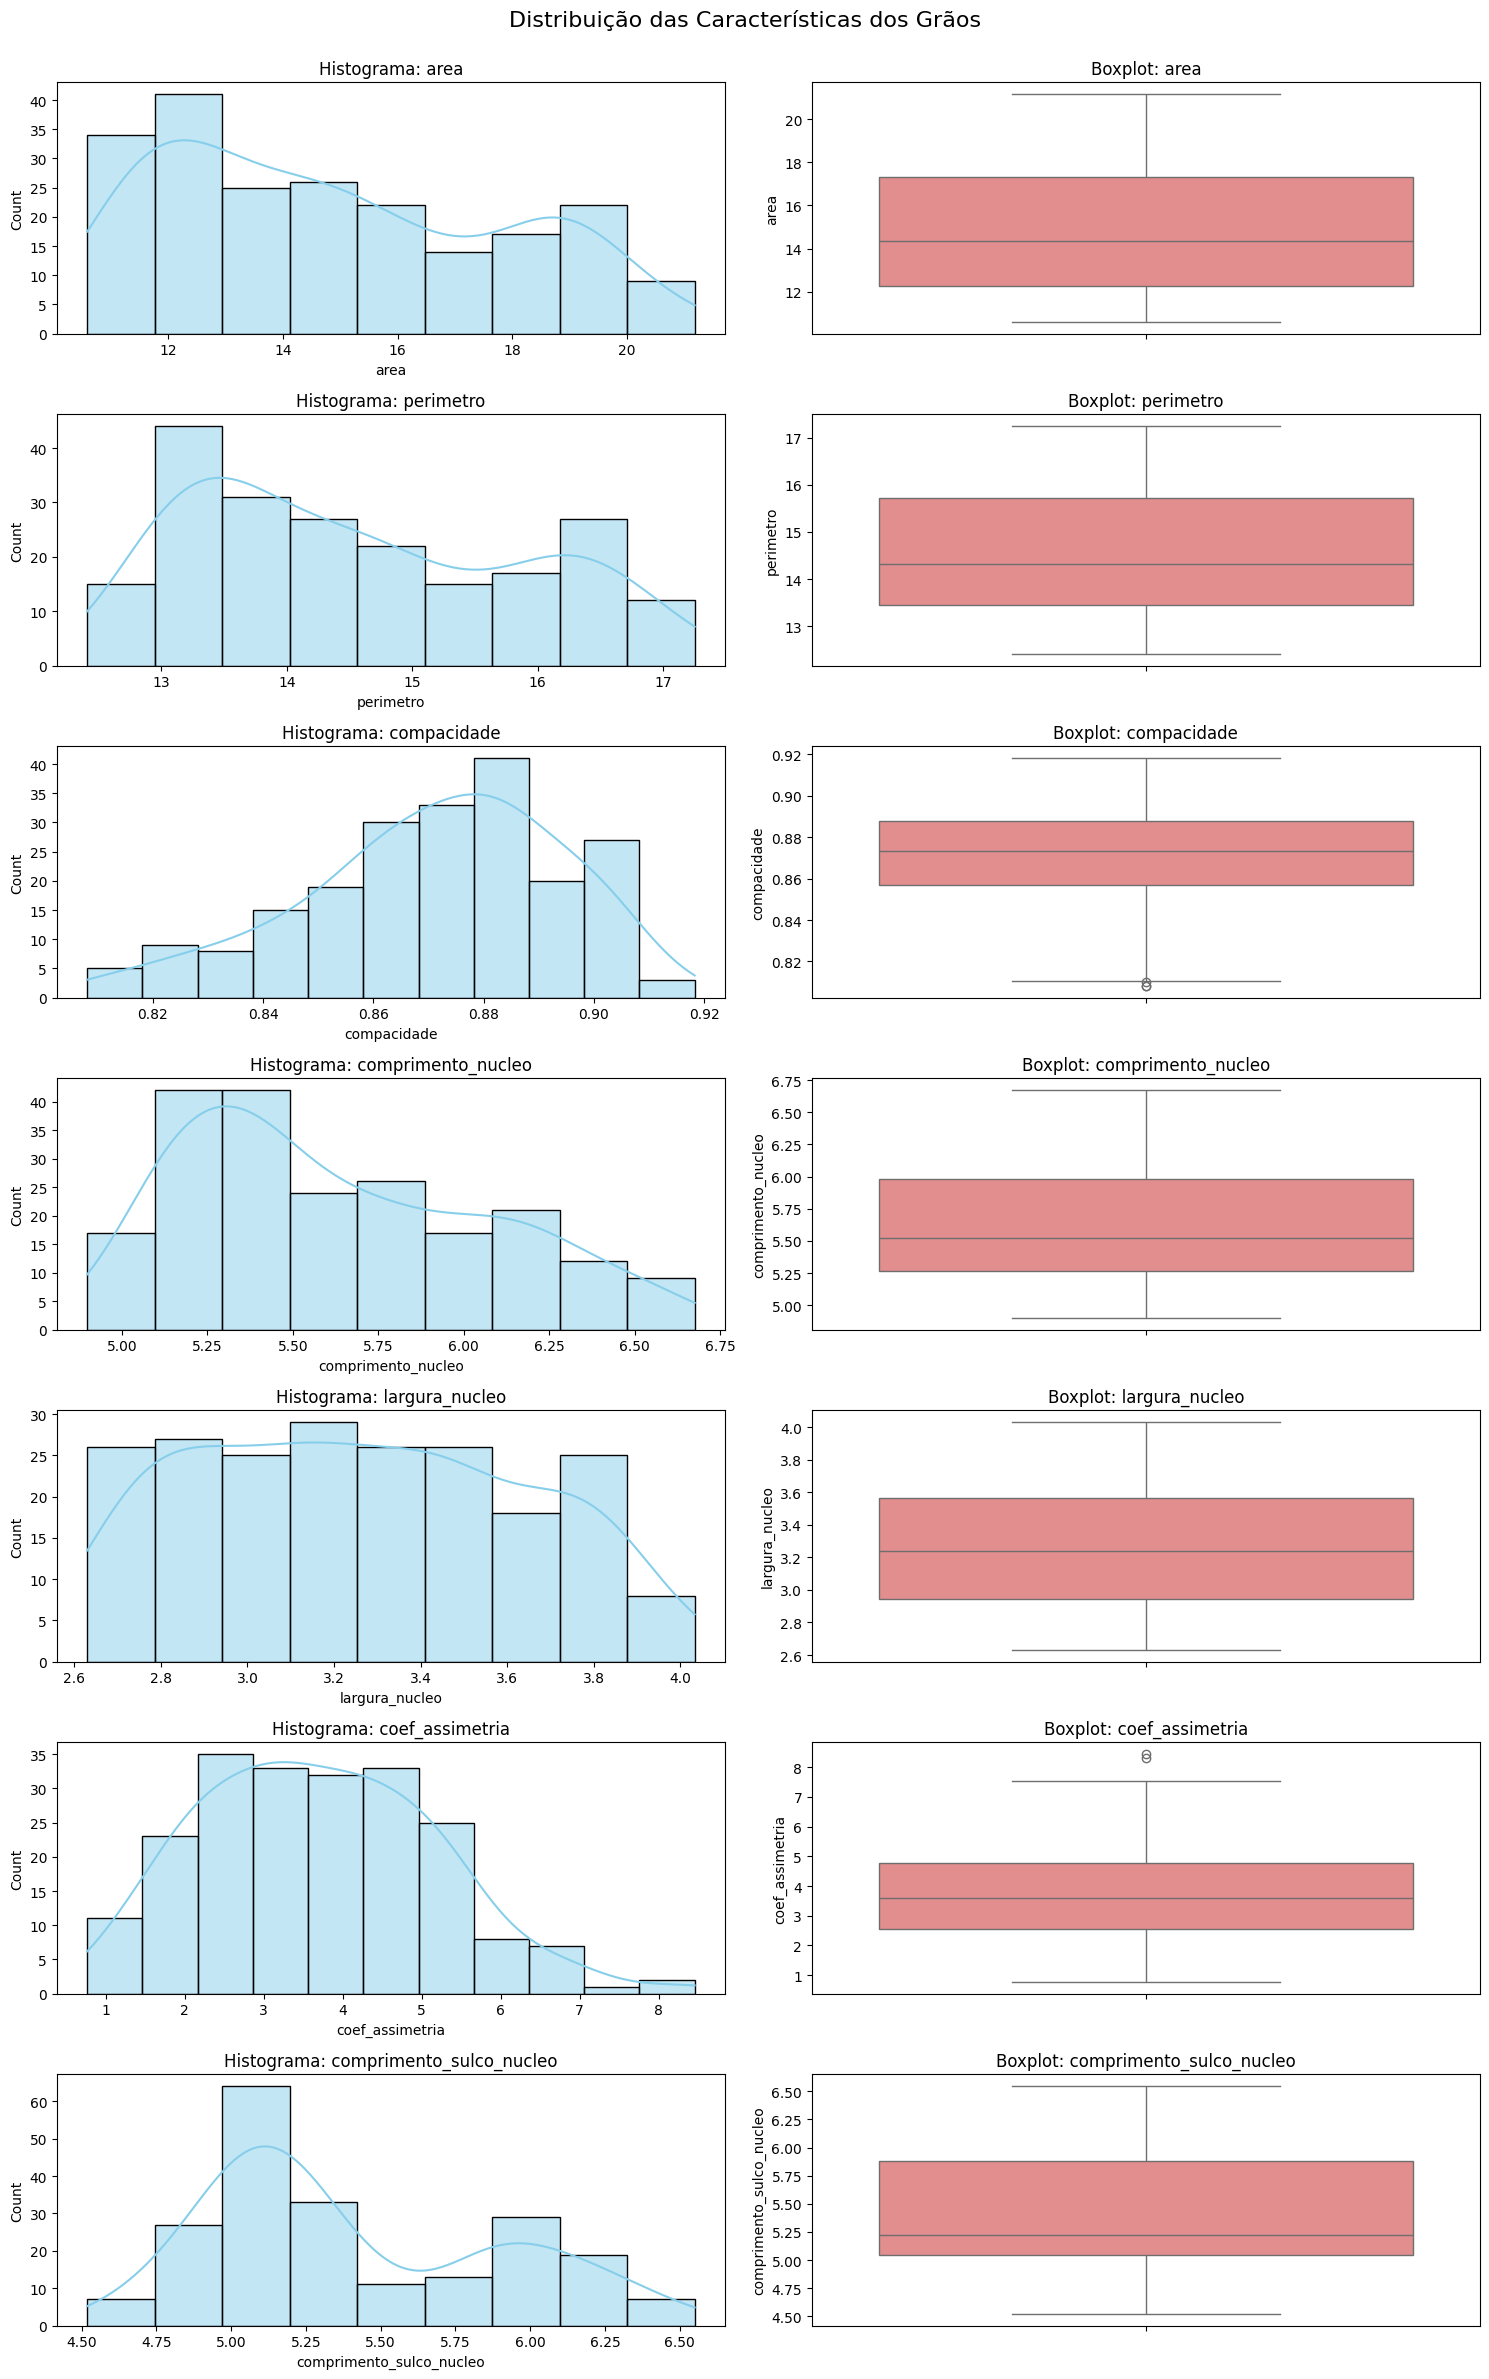

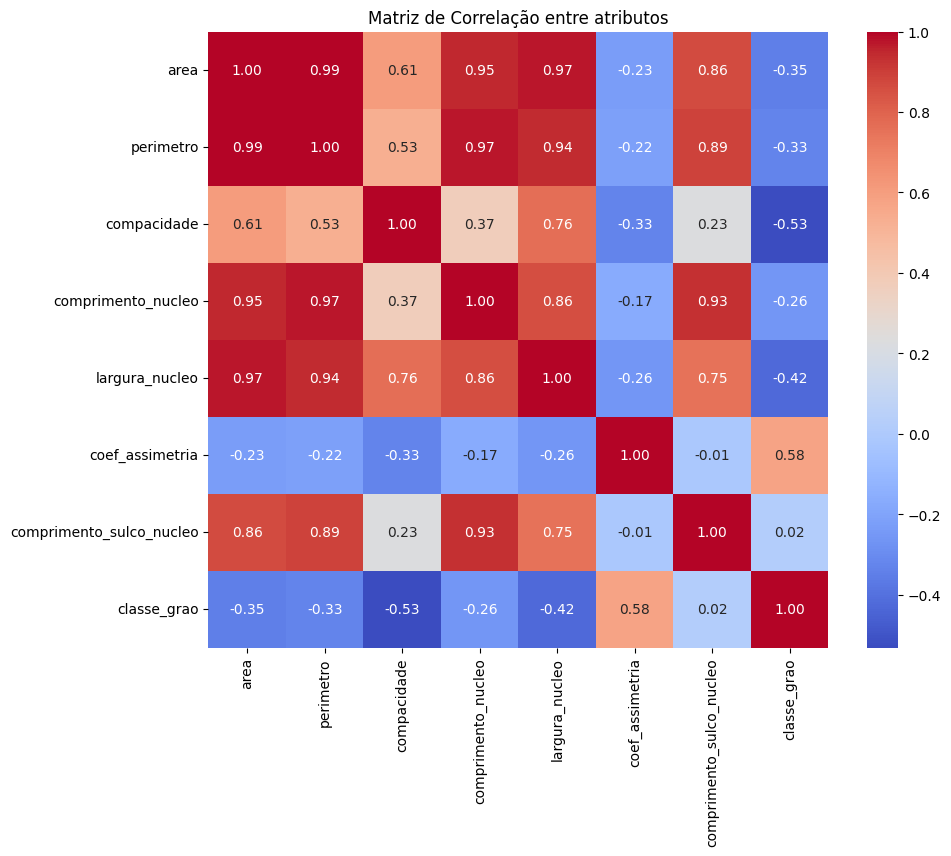

In [23]:
import matplotlib.pyplot as plt 
import seaborn as sns 

fig, axes = plt.subplots(7, 2, figsize=(15, 25))
fig.suptitle('Distribuição das Características dos Grãos', fontsize=16)

for i, col in enumerate(colunas[:-1]):
    # Histograma
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histograma: {col}')
    # Boxplot
    sns.boxplot(y=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show();

# Matriz de correlação
plt.figure(figsize=(10, 8))
matriz_correlacao = df.corr()
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação entre atributos')
plt.show();


# Tratamento de valores ausentes

In [24]:
df.isnull().sum()

area                        0
perimetro                   0
compacidade                 0
comprimento_nucleo          0
largura_nucleo              0
coef_assimetria             0
comprimento_sulco_nucleo    0
classe_grao                 0
dtype: int64

# Separação e escalonamento das features

In [25]:
from sklearn.preprocessing import StandardScaler

# Separação
X = df.drop(columns='classe_grao')
y = df['classe_grao']

# Escalonamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [26]:
X_scaled_df

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco_nucleo
0,0.142098,0.215462,0.000061,0.304218,0.141702,-0.986152,-0.383577
1,0.011188,0.008224,0.428515,-0.168625,0.197432,-1.788166,-0.922013
2,-0.192067,-0.360201,1.442383,-0.763637,0.208048,-0.667479,-1.189192
3,-0.347091,-0.475333,1.039381,-0.688978,0.319508,-0.960818,-1.229983
4,0.445257,0.330595,1.374509,0.066666,0.805159,-1.563495,-0.475356
...,...,...,...,...,...,...,...
205,-0.915515,-1.043321,0.309736,-1.112048,-0.736716,-0.046135,-1.097413
206,-1.246235,-1.288937,-0.844122,-1.105261,-1.230328,0.416540,-0.826156
207,-0.567571,-0.690247,0.733948,-0.888070,-0.070604,3.076588,-0.718060
208,-1.036090,-1.035645,-0.801701,-1.026077,-1.121521,-0.068135,-0.742535


# Implementação

## Separação

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_teste, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

## Treinamento

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

modelos = {
    'KNN': KNeighborsClassifier(n_neighbors=5), 
    'RandomForest': RandomForestClassifier(random_state=42), 
    'SVM': SVC(random_state=42)
}

results = {}

for nome, model in modelos.items(): 
    print(f'\n---Treinando e Avaliando: {nome}---\n')
    # Treinamento
    model.fit(X_train, y_train)
    y_pred = model.predict(X_teste)
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results[nome] = {
        'Acurácia': accuracy, 
        'Precisão': precision, 
        'Recall': recall, 
        'F1-Score': f1, 
        'Matriz_Confusao': cm
    }

    print(f"Acurácia: {accuracy:.4f}")
    print(f"Relatório de Classificação:\n{classification_report(y_test, y_pred, zero_division=0)}")
    print(f"Matriz de Confusão:\n{cm}")



---Treinando e Avaliando: KNN---

Acurácia: 0.8730
Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.84      0.76      0.80        21
           2       0.90      0.90      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

Matriz de Confusão:
[[16  2  3]
 [ 2 19  0]
 [ 1  0 20]]

---Treinando e Avaliando: RandomForest---

Acurácia: 0.9206
Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.94      0.81      0.87        21
           2       0.95      0.95      0.95        21
           3       0.88      1.00      0.93        21

    accuracy                           0.92        63
   macro avg       0.92      0.92      0.92        63
weighted avg       0.92      0.92      0.92        63

Matriz de Co

# Otimização do modelo

In [29]:
from sklearn.model_selection import GridSearchCV

print(f'\nOtimização do SVM com Grid Search ---\n')
param_grid_svm = {
    'C': [0.1, 1, 10, 100], 
    'gamma': ['scale', 'auto', 0.1, 0.01], 
    'kernel': ['rbf', 'linear']
}

gird_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy', n_jobs=1)

gird_search_svm.fit(X_train, y_train)

print(f"Melhores Parâmetros Encontrados: {gird_search_svm.best_params_}")
print(f"Melhor Acurácia no Treino (CV): {gird_search_svm.best_score_:.4f}")

# Reavaliação no Conjunto de Teste
best_svm = gird_search_svm.best_estimator_
y_pred_tuned = best_svm.predict(X_teste)

# Métricas Otimizadas
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\n--- Desempenho do SVM Otimizado ---")
print(f"Acurácia no Teste (Otimizada): {accuracy_tuned:.4f}")
print(f"Relatório de Classificação (Otimizado):\n{classification_report(y_test, y_pred_tuned, zero_division=0)}")
print(f"Matriz de Confusão (Otimizada):\n{confusion_matrix(y_test, y_pred_tuned)}")



Otimização do SVM com Grid Search ---

Melhores Parâmetros Encontrados: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Melhor Acurácia no Treino (CV): 0.9731

--- Desempenho do SVM Otimizado ---
Acurácia no Teste (Otimizada): 0.8889
Relatório de Classificação (Otimizado):
              precision    recall  f1-score   support

           1       0.85      0.81      0.83        21
           2       0.95      0.86      0.90        21
           3       0.88      1.00      0.93        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63

Matriz de Confusão (Otimizada):
[[17  1  3]
 [ 3 18  0]
 [ 0  0 21]]
